**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data= pd.read_csv('CitasDigital_sin_nulos.csv') 

In [11]:
data.info

<bound method DataFrame.info of      Unnamed: 0      BDC        Fecha             Nombre Cliente   \
0             0     Saul   Abril 2025                  Guillermo    
1             1     Saul   Abril 2025                    Roberto    
2             2     Saul   Abril 2025                     Irving    
3             3     Saul   Abril 2025                    Oswaldo    
4             4     Saul   Abril 2025                    Rodrigo    
..          ...       ...         ...                         ...   
648         671       Ana  2026-07-22             Maira Escalante   
649         672  Ignacio   2026-07-22                Zaira Macip    
650         673  Ignacio   2026-07-27            Julio Hernandez    
651         674  Ignacio   2026-07-24           Xhunaxhi Vicente    
652         675  Ignacio   2026-07-29  DR Jairo Rodriguez Farias    

    Estatus de Lead  Potencial de compra  PDM  SDC  Venta Asesor Asignado  \
0       Finalizado                  0.90  1.0  0.0    0.0     

In [14]:
# Añadí al principio estas variables por que si bien la parte de PMD y SDC cuenta con valores voleanos pues solo es 0 y 1
# Queria asegurarme que no hubiera ningun dato fuera de lugar
columnas_cuantitativas = ['Potencial de compra', 'PDM', 'SDC', 'Venta']

cuantitativas = data[columnas_cuantitativas]
cualitativas = data.drop(columns=columnas_cuantitativas)

cuantitativas.head()

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,1.0
4,0.90,1.0,0.0,0.0


<Figure size 1500x800 with 0 Axes>

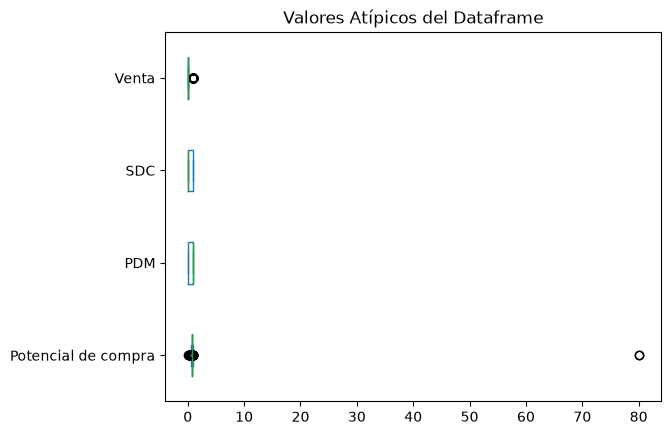

In [22]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [15]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
SDC                    2.50
Venta                  0.00
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
SDC                   -1.50
Venta                  0.00
dtype: float64


In [16]:
#Obtenemos datos limpios del Dataframe
data3_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,NaN,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,NaN,0.0,0.0,0.0
650,NaN,1.0,0.0,0.0
651,NaN,1.0,1.0,NaN


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data3_iqr.isnull().sum()
valores_nulos

Potencial de compra    73
PDM                     0
SDC                     0
Venta                  58
dtype: int64

In [18]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data4_iqr=data3_iqr.copy()
data4_iqr=data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.80,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,0.80,0.0,0.0,0.0
650,0.80,1.0,0.0,0.0
651,0.80,1.0,1.0,0.0


In [19]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limpios

,Unnamed: 0,BDC,Fecha,Nombre Cliente,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Comentarios Adicionales,Potencial de compra,PDM,SDC,Venta
0,0,Saul,Abril 2025,Guillermo,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...,0.90,1.0,0.0,0.0
1,1,Saul,Abril 2025,Roberto,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin comentario adicional,0.80,0.0,0.0,0.0
2,2,Saul,Abril 2025,Irving,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025,0.85,0.0,0.0,0.0
3,3,Saul,Abril 2025,Oswaldo,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",Sin comentario adicional,0.90,0.0,0.0,0.0
4,4,Saul,Abril 2025,Rodrigo,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
648,671,Ana,2026-07-22,Maira Escalante,Activo,Pedro Antonio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,1.0,0.0
649,672,Ignacio,2026-07-22,Zaira Macip,Activo,Aurelio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,0.0,0.0,0.0
650,673,Ignacio,2026-07-27,Julio Hernandez,Activo,Victor,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,0.0,0.0
651,674,Ignacio,2026-07-24,Xhunaxhi Vicente,Activo,Ignacio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,1.0,0.0


In [20]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Unnamed: 0                                  0
BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Estatus de Lead                             0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Comentarios Adicionales                     0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
dtype: int64

In [ ]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("CitasDigital_outliers_cuantiles.csv")